# Swin Transformer


<font color="red">**0 前言**</font><br>
&nbsp;&nbsp;&nbsp;&nbsp;0.1 Swin Transformer为什么会被提出？<br>
&nbsp;&nbsp;&nbsp;&nbsp;0.2 它主要想解决ViT的什么问题？<br>

<font color="red">**1 Swin Transformer的核心处理机制**</font><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1 Window Attention在做什么？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2 Shifted Window为什么能建立跨窗口连接？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.3 W-MSA与SW-MSA是如何交替工作的？<br>

**2 Swin Transformer的整体框架**<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1 从Patch Partition到Linear Embedding<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2 为什么它是层次化Transformer？<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.3 Patch Merging怎样实现尺度变化？<br>

**3 Swin Transformer的完整流程**<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1 一张图进入Swin后会经历哪些步骤？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2 各个Stage中的特征图尺寸如何变化？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3 最后如何得到视觉任务需要的输出表示？<br>

**4 学习Swin时最该抓住的几个点**<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1 它和ViT最本质的区别是什么？<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2 “局部计算 + 跨窗连接 + 层次化表示”该如何整体理解？<br>


## 0 前言

Swin Transformer 可以理解成：**在 ViT 的基础上，进一步把 Transformer 改造成更适合视觉任务的结构。**

ViT 证明了纯 Transformer 也能做图像建模，但它的标准全局自注意力在高分辨率图像上计算代价较高，而且整体结构不够层次化，不太像 CNN 那样天然形成多尺度特征。

Swin Transformer 的核心思路就是三点：

1. 把注意力限制在局部窗口中计算。
2. 通过窗口平移让不同窗口之间建立信息交互。
3. 通过分阶段处理形成层次化表示。

所以学习这篇论文时，主要抓住它的**处理机制、整体框架和数据流**即可。


### 0.1 Swin Transformer为什么会被提出？

提出它的直接原因是：**标准 ViT 在视觉任务里还不够高效，也不够通用。**

一方面，图像分辨率升高后，token 数量会明显增加，而全局自注意力的计算和显存开销也会随之变大。另一方面，目标检测、语义分割这类任务又很依赖多尺度特征表示，而标准 ViT 并不天然具备这种层次化结构。

因此，Swin Transformer 想在保留 Transformer 建模能力的同时，让它：

- 计算更高效
- 更适合高分辨率图像
- 更适合作为通用视觉主干网络


### 0.2 它主要想解决ViT的什么问题？

如果只看核心，Swin Transformer 主要在解决 ViT 的两个问题：

- **全局注意力成本高**：token 一多，计算量增长很快
- **缺少层次化表示**：特征不会随着层数加深自然形成多尺度结构

对应地，Swin 给出的解决方式也很明确：

- 用 `window-based attention` 把全局计算改成局部计算
- 用 `shifted window` 建立跨窗口连接
- 用 `patch merging` 逐步降低分辨率、增强语义表达

因此可以把 Swin Transformer 概括成一句话：**它是在用更适合视觉任务的方式，重新组织 Transformer 的注意力计算和特征演化过程。**


## 1 Swin Transformer的核心处理机制

### 1.1 Window Attention在做什么？

Swin Transformer 最先做的关键改动，就是**不再让每个 token 和整张图上的所有 token 做全局注意力，而是只在一个局部窗口内部做自注意力。**

如果放在普通 ViT 里理解，一张图被切成 patch 以后，所有 patch token 会放在同一条序列里，每个 token 都可以和其他所有 token 交互。这种做法的好处是全局建模直接，但问题也很明显：token 数量一多，注意力代价就会迅速升高。

Swin 的想法则更接近视觉任务本身的局部性：

- 先把特征图按空间位置划分成若干个小窗口
- 每个窗口内部包含一小块相邻 token
- 注意力计算只发生在这个窗口内部

这就是 `Window-based Multi-Head Self-Attention`，通常记作 `W-MSA`。

可以把它直观理解成：**每个 token 先只和自己附近的一小片区域交流，而不是一开始就和整张图的所有位置通信。**

举个最简单的例子，如果当前特征图被划成很多个 `M × M` 的窗口，那么每个窗口里只有 `M^2` 个 token。做注意力时，一个 token 只需要看同窗口中的其他 token，而不需要看窗口外的 token。

这样做带来两个直接结果：

- **计算范围被限制在局部**，复杂度显著下降
- **局部结构更容易保留**，因为窗口里的 token 本来就在空间上彼此相邻

为什么说它能明显降低复杂度？核心在于比较对象变少了。

假设整张图一共有 `N` 个 token：

- 全局自注意力里，每个 token 都要和其余 `N` 个 token 比较，代价大致随 `N^2` 增长
- 窗口注意力里，每个 token 只和窗口内大约 `M^2` 个 token 比较；如果窗口大小固定，那么整体复杂度会更接近随 `N` 线性增长

这就是 Swin 能更好处理高分辨率图像的一个关键原因。因为当图像变大时，token 总数 `N` 会增加，但只要窗口大小不变，**单个窗口里的计算规模不会跟着图像分辨率一起爆炸。**

不过，Window Attention 也有一个很自然的限制：

**如果注意力永远只在固定窗口内部计算，那么不同窗口之间的信息就不容易直接交换。**

这正是下一节 `Shifted Window` 要解决的问题。也就是说，`W-MSA` 先负责把计算成本压下来，而跨窗口的信息流动则交给后面的机制补上。


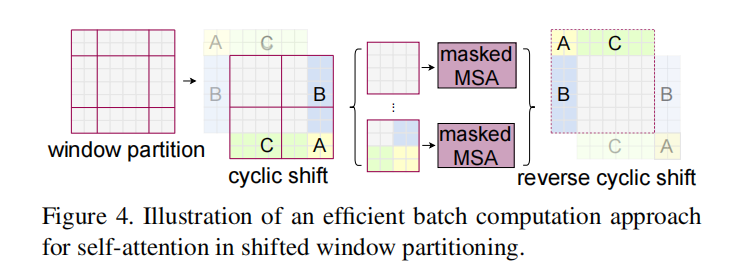

### 1.2 Shifted Window为什么能建立跨窗口连接？

前一节的 `Window Attention` 虽然把计算量降下来了，但它也带来一个明显问题：**如果窗口划分始终固定，那么一个 token 只能反复和同一个窗口里的邻居交互，窗口外的信息就很难进来。**

这意味着什么？意味着模型虽然有了高效的局部建模能力，但不同窗口之间像是被“边界”隔开了。对于视觉任务来说，这显然不够，因为真实图像中的目标往往会跨越多个局部区域，不可能刚好完整落在一个窗口里。

Swin 的解决办法非常巧妙：**下一层不要继续沿用原来的窗口划分，而是把窗口整体平移一个偏移量，再在新的窗口划分下做一次局部注意力。**

这就是 `Shifted Window Multi-Head Self-Attention`，通常记作 `SW-MSA`。

它的关键点不在于“窗口变大了”，也不在于“重新做全局注意力”，而在于：

**原来属于不同窗口的 token，在窗口平移之后，可能会被分到同一个新窗口里。**

一旦它们进入同一个新窗口，就可以在这一次局部注意力中直接相互看见、交换信息。这样一来，原先被固定窗口边界隔开的区域，就通过“下一层重新分组”的方式连通起来了。

可以把它想成两轮局部通信：

1. 第一轮按原始窗口划分做 `W-MSA`，先让每个局部区域内部充分交互。
2. 第二轮把窗口平移后做 `SW-MSA`，让原来分属不同窗口的 token 获得新的邻居关系。

这样连续两轮下来，信息就不再被严格困在某一个固定窗口里，而是可以逐步跨窗口传播。

这里最值得抓住的直觉是：

- `W-MSA` 负责高效的局部建模
- `SW-MSA` 负责打破固定窗口的边界限制

所以 `Shifted Window` 的本质，不是把局部注意力变回全局注意力，而是**用一种几乎不增加太多计算成本的方式，让局部窗口之间产生连接。**

从信息流的角度看，它相当于在说：

**我仍然只做局部计算，但我会改变“谁和谁被分在一起”的方式，于是跨区域的信息也能逐步传递。**

这也是 Swin Transformer 很核心的一点：它没有直接追求“一步到位的全局交互”，而是采用“局部计算 + 逐层传播”的方式，在效率和建模能力之间做平衡。


#### 1.2.1 窗口到底是怎么移位的？

这里不能只停留在“平移一下窗口”这种直觉描述上，因为 Swin 的关键就在于它**不是随便平移**，而是有明确规则的。

假设窗口大小记作 `M × M`，那么 `SW-MSA` 通常会把特征图沿高和宽两个方向各平移：

$$
\frac{M}{2}
$$

也就是**半个窗口大小**。

比如，如果窗口大小是论文里常见的 `7 × 7`，那么 shift size 就可以理解成接近“半个窗口”的那个偏移量。这里最重要的不是死记具体数字，而是记住设计原则：

**平移的目标，是让原来被窗口边界分开的 token，在下一层尽可能重新落到同一个窗口里。**

为什么偏偏是“半个窗口”最自然？因为如果偏移太小，那么重新分组的效果不明显，很多 token 还是和原来差不多的一批邻居待在一起；如果偏移太大，又会破坏局部性，甚至让窗口划分变得不均衡。

而平移半个窗口，恰好可以让原来相邻的两个窗口在下一次划分时出现大面积“交叉重组”。于是原本属于不同窗口边界两侧的 token，就更容易进入同一个新窗口。



#### 1.2.2 真按平移后的窗口去切，会遇到什么问题？

如果你直接在脑子里把特征图平移半个窗口，再重新切窗口，很快就会发现一个麻烦：

**边界处会出现很多不规则的小块。**

原因很简单。原来按 `M × M` 整齐切分时，窗口是规则的；但平移以后，最左边、最上边、最右边、最下边这些区域就可能被切成大小不一致的碎片。

这在概念上当然还能画出来，但在实现上会很不方便，因为：

- 每个窗口大小不再统一
- 很难高效地把所有窗口并行打包计算
- 注意力矩阵的批处理也会变得麻烦

而 Swin 的目标并不是只提出一个“概念上可行”的 shifted window，而是要提出一个**工程上也高效**的 shifted window。

所以真正的实现不会傻乎乎地直接处理这些不规则边界，而是会改用一种更整齐的办法：`cyclic shift`。


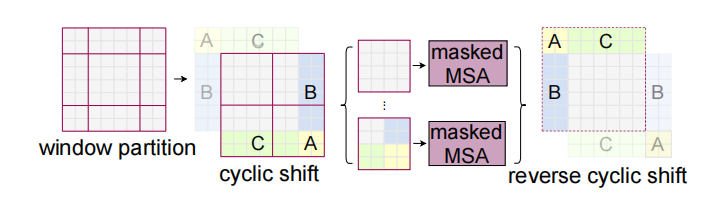

#### 1.2.3 什么是cyclic shift，它解决了什么问题？

`cyclic shift` 可以先粗略理解成：**把特征图像循环数组一样滚动平移。**

比如，向左上平移一部分以后，从左边和上边“移出去”的内容，并不会真的消失，而是会从另一侧补回来。这样一来，整张特征图的尺寸保持不变，重新划分窗口时，仍然可以切出一批规则的 `M × M` 窗口。

它带来的最大好处是：

- 窗口大小仍然统一
- 所有窗口仍然可以并行计算
- 实现上不需要真的维护一堆不规则碎片窗口

从工程角度看，Swin 实际上是在做这样一件事：

1. 先对整张特征图做 cyclic shift。
2. 再按普通方式切成规则窗口。
3. 在这些规则窗口里做注意力。

这样，表面上看，好像还是在一批规则窗口里算注意力；但由于前面先做了循环平移，**这些规则窗口里的 token 组合关系已经变了**，因此就等价于实现了 shifted window 的重组效果。

不过，这里会立刻冒出下一个更关键的问题：

**如果循环平移后，原本在特征图两端、其实空间上并不相邻的 token 被卷到同一个窗口里，那它们难道也应该彼此做注意力吗？**

答案是：不应该。这正是 `masked MSA` 存在的原因。


#### 1.2.4 为什么还需要masked MSA？

这是 Swin 里最容易被忽略、但实际上非常关键的一步。

`cyclic shift` 只是为了让实现保持规则、高效，但它会带来一个“假邻居”问题：

- 有些 token 因为循环平移，被卷到了同一个窗口里
- 但它们在原始空间布局里并不属于同一个 shifted window 区域
- 如果直接让它们互相做注意力，就会引入错误的连接

所以，Swin 不能只是“shift 一下再算注意力”，还必须额外告诉模型：

**同一个规则窗口里，并不是所有 token 都真的彼此可见。**

这就是 `masked MSA` 的作用。它会对注意力矩阵加一个 mask，把那些“虽然被卷到同一个 batch window 里、但本来不属于同一个 shifted window 区域”的 token 对屏蔽掉。

于是最终允许发生注意力的，只剩下：

- 在 shifted window 语义上真正同属一个窗口区域的 token

而那些只是因为 cyclic shift 才临时拼到一起的 token，会被 mask 掉，注意力权重相当于不会在它们之间建立连接。

所以可以把这套机制完整地理解成：

- `cyclic shift` 解决的是**规则切窗与高效并行计算**的问题
- `attention mask` 解决的是**哪些 token 真正应该互相可见**的问题

两者缺一不可。

如果没有 cyclic shift，shifted window 很难高效实现；如果没有 mask，循环平移又会引入不正确的跨边界连接。

因此，Swin 的 `SW-MSA` 真正完整的工作方式应该记成：

**先做 cyclic shift，再切规则窗口，然后在窗口内做 masked self-attention。**


#### 1.2.5 把这套机制压成一句话

如果只记一句最关键的话，那就是：

**Swin 的 shifted window 不是简单把窗口挪一下，而是通过“半窗口偏移 + cyclic shift + attention mask”这三步，在保持规则计算的前提下，实现真实有效的跨窗口连接。**

这也是为什么 `SW-MSA` 会被看成 Swin Transformer 最核心的技术创新之一。因为它解决的不是单一问题，而是同时解决了：

- 跨窗口信息流动
- 规则窗口并行计算
- 边界错误连接控制

后面再看 `1.3 W-MSA 与 SW-MSA 交替工作` 时，就应该把这整套实现细节一起带进去理解，而不只是把它当成一句抽象的“窗口平移”。


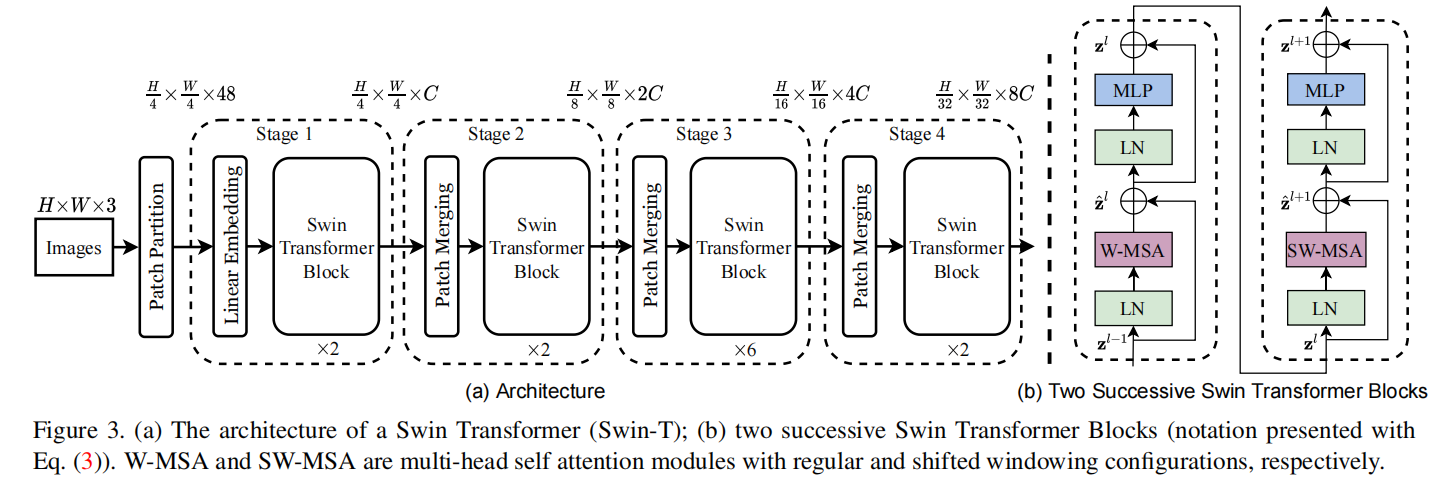

### 1.3 W-MSA与SW-MSA是如何交替工作的？

前两节分别讲了 `W-MSA` 和 `SW-MSA`，但 Swin Transformer 真正有效的地方，不只是“有这两个机制”，而是：**它把这两种局部注意力按固定方式交替起来。**

可以把最基本的模式理解成一对连续的 block：

1. 先用一次 `W-MSA`
2. 再接一次 `SW-MSA`

也就是说，模型在重复这样一个节奏：

`固定窗口内建模 -> 平移窗口后重新建模`

这里两者的分工很清楚：

- `W-MSA` 先让每个局部窗口内部完成充分的信息交互
- `SW-MSA` 再通过窗口平移，打破原来固定窗口的边界

这样一来，一个 token 在当前层先和自己窗口里的邻居交流，到了下一层，又会因为窗口重新分组而接触到新的邻居。于是随着层数加深，信息就会逐步传播到更远的位置。

所以虽然**单次注意力始终只是局部的**，但经过多层交替堆叠之后，模型的有效感受范围会越来越大。这正是 Swin 在不做全局注意力的前提下，仍然能够建立较大范围上下文联系的原因。

如果从整体结构上理解，这种交替机制可以概括成：

- 一层负责稳定的局部建模
- 下一层负责跨窗口的信息桥接
- 多层重复后，局部信息会逐步演化成更大范围的语义表示

同时要注意，Swin 并没有推翻标准 Transformer block 的基本骨架。除了把注意力改成 `W-MSA / SW-MSA` 之外，它仍然保留了常见的：

- Layer Normalization
- MLP / Feed-Forward Network
- Residual Connection

因此可以把它理解成：**Swin 保留了 Transformer block 的基本形式，但重新设计了相邻层中注意力的组织方式。**

这一节最后压成一句话就是：

**`W-MSA` 与 `SW-MSA` 的交替，本质上是在保持局部计算高效率的同时，让信息能够跨窗口、跨层地逐步传播。**
